In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
def load_yield_data():

    yield_data = pd.read_csv('data/EU_yield_curves_combined.csv')

    expected_columns = ['EU_1Y', 'EU_5Y', 'EU_10Y', 'EU_20Y', 'EU_30Y']

    if not all(col in yield_data.columns for col in expected_columns):
        raise ValueError('The expected columns do not exist in the dataframe')

    yield_data['DATE'] = pd.to_datetime(yield_data['DATE'])
    yield_data.set_index('DATE', inplace = True)

    return yield_data

yield_data = load_yield_data()

In [32]:
# Check for missing values
print('Missing values in each column:')
print(yield_data.isna().sum())

Missing values in each column:
EU_1Y     0
EU_5Y     0
EU_10Y    0
EU_20Y    0
EU_30Y    0
dtype: int64


In [31]:
# Check for zero variance
print('Variance of each column:')
print(yield_data.var())

Variance of each column:
EU_1Y     2.680141
EU_5Y     2.481493
EU_10Y    2.481108
EU_20Y    2.418795
EU_30Y    2.272659
dtype: float64


In [37]:
print('Condition number of the data matrix:')
condition_number = np.linalg.cond(yield_data[['EU_1Y', 'EU_5Y', 'EU_10Y', 'EU_20Y', 'EU_30Y']])
print(round(condition_number, 2))

Condition number of the data matrix:
176.77


In [26]:
def load_economic_data():
    ...

econ_data = load_economic_data()

In [27]:
def calculate_curve_measure(df: pd.DataFrame):

     measures = pd.DataFrame(index = df.index)

     measures['Level'] = df['EU_10Y']

     # Slope measures
     measures['Slope_1s10s'] = df['EU_10Y'] - df['EU_1Y']
     measures['Slope_5s30s'] = df['EU_30Y'] - df['EU_5Y']

     measures['Butterfly_5s'] = df['EU_5Y'] - 0.5 * (df['EU_1Y'] + df['EU_10Y'])
     measures['Butterfly_10s'] = df['EU_10Y'] - 0.5 * (df['EU_5Y'] + df['EU_20Y'])
     measures['Butterfly_20s'] = df['EU_20Y'] - 0.5 * (df['EU_10Y'] + df['EU_30Y'])

     return measures

curve_measures = calculate_curve_measure(yield_data)

In [28]:
def perform_yield_pca(yield_data: pd.DataFrame):

    numeric_data = yield_data.select_dtypes(include=['float64', 'int64'])

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(yield_data)

    pca = PCA(n_components = 3)
    components = pca.fit_transform(scaled_data)

    pca_df = pd.DataFrame(components,
                          index = yield_data.index,
                          columns = ['PC1', 'PC2', 'PC3']
                          )

    explained_variance = pca.explained_variance_ratio_

    return pca_df, explained_variance, pca

In [29]:
yield_pca_df, yield_exp_variance, yield_pca_model = perform_yield_pca(yield_data)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [30]:
print("Yield PCA Explained Variance Ratio")
for i, var in enumerate(yield_exp_variance):
    print(f'PC{i + 1}: {var:.4f} ({var*100:.2f})')

Yield PCA Explained Variance Ratio
PC1: 0.9283 (92.83)
PC2: 0.0678 (6.78)
PC3: 0.0030 (0.30)


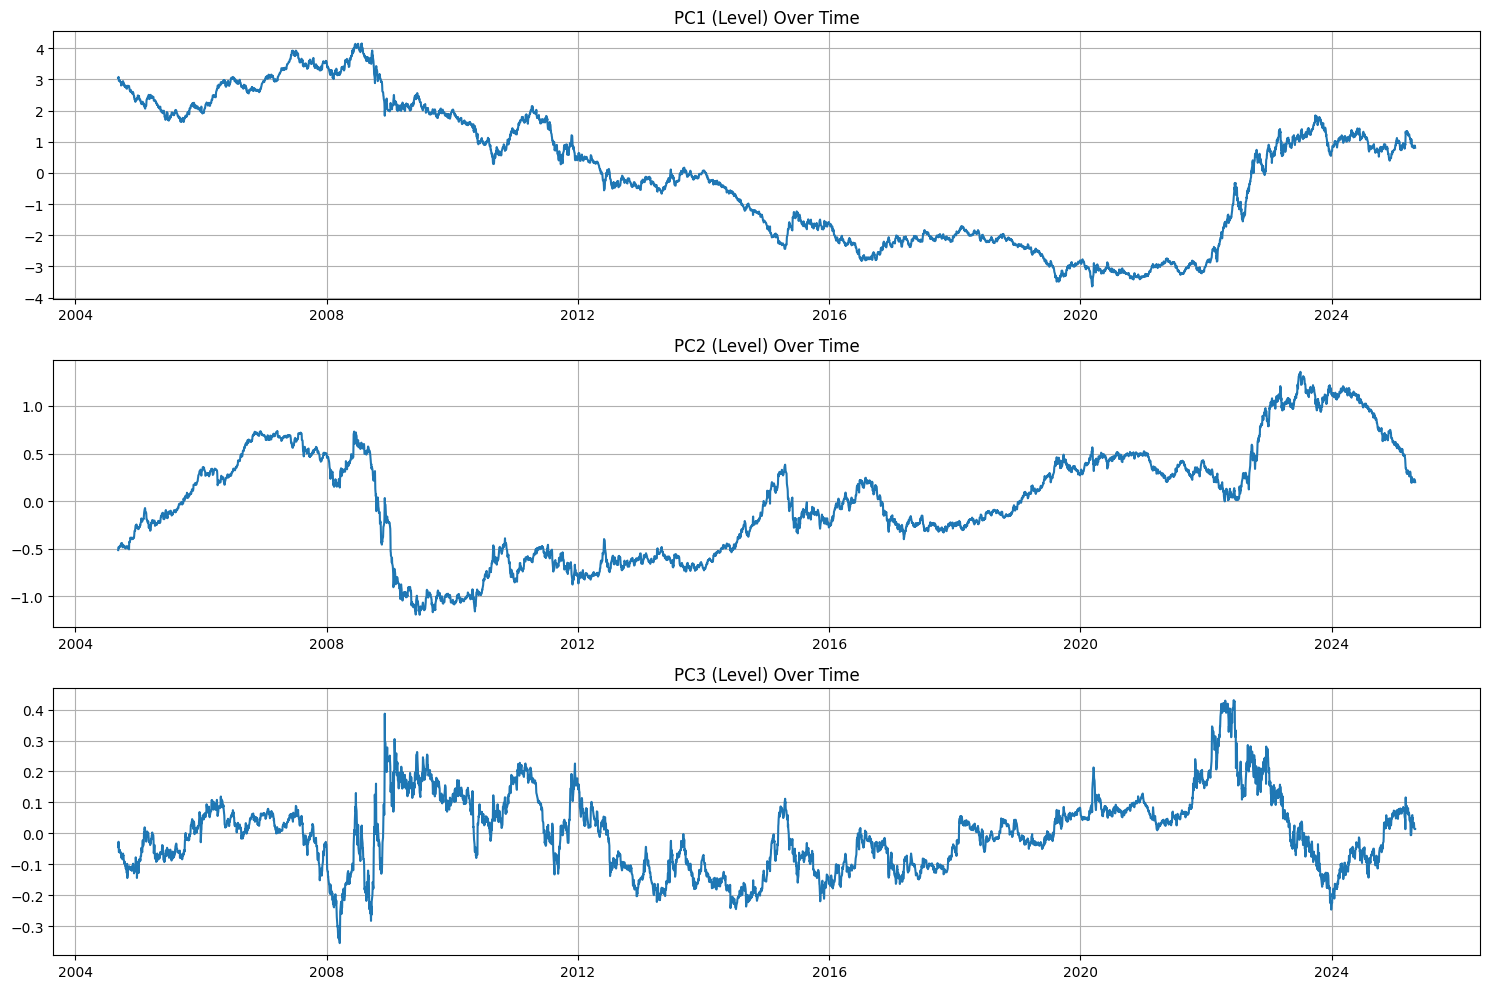

In [36]:
plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
plt.plot(yield_pca_df['PC1'])
plt.title('PC1 (Level) Over Time')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(yield_pca_df['PC2'])
plt.title('PC2 (Level) Over Time')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(yield_pca_df['PC3'])
plt.title('PC3 (Level) Over Time')
plt.grid(True)

plt.tight_layout()
plt.savefig('images/yield_pca_components.png')

In [ ]:
def prepare_regime_features(yield_pca_df: pd.DataFrame, econ_data: pd.DataFrame, lag: int = 1):
    ...

regime_features = prepare_regime_features()

In [ ]:
def detect_regimes(features: pd.DataFrame, n_regimes: int = 3):
    ...

regimes, kmeans_model = detect_regimes(regime_features)

In [ ]:
regime_features['regime'] = regimes

regime_stats = regime_features.groupby('regime').mean()
print('\nRegime Characteristics:')
print(regime_stats)

In [ ]:
plt.figure(figsize=(15,10))
for regime in range(3):
    regime_dates = regime_features.index[regime_features['regime'] == regime]
    plt.scatter(regime_dates, yield_data.loc[regime_dates, 'EU_10Y'],
                label = f'Regime {regime}', alpha = 0.7)

plt.title('Regime vs 10Y Yield')
plt.ylabel('10Y Yield (%)')
plt.legend()
plt.grid(True)
plt.savefig('images/regime_detection.png')

In [ ]:
def analyze_mean_reversion(curve_measures, regimes):
    ...

mean_reversion_stats = analyze_mean_reversion(curve_measures, regimes)

print('\nMean-Reversion Statistics by Regime:')
print(mean_reversion_stats)

In [ ]:
def calculate_zscore_by_regime(series, regimes, window:int = 60):
    ...

z_score = pd.DataFrame(index = curve_measures.index)

In [ ]:
def construct_portfolio(signals, max_positions: int = 3, max_allocation: float = 0.3):
    ...

portfolio_weights = construct_portfolio(z_score)

portfolio_weights.to_csv('data/portfolio_weights.csv')

In [ ]:
def calculate_pnl():
    ...

pnl = calculate_pnl()

In [ ]:
cum_pnl = pnl.cumsum()

plt.figure(figsize=(15,10))
plt.plot(cum_pnl)
plt.title('Cumulative PNL')
plt.grid(True)
plt.savefig('images/cumulative_pnl.png')
plt.show()

In [ ]:
def calculate_performance_metrics(returns):
    ...

In [ ]:
performance = calculate_performance_metrics(pnl)
print('\nPerformance Metrics:')

In [ ]:
def calculate_risk_exposure():
    ...

In [ ]:
risk_exposures = calculate_risk_exposure()

